# DART 공시 본문 수집 — v3.5 신규 클래스

## 목적
v3(3클래스)에 없는 **전환사채 / 자기주식 / 합병·분할** 3개 클래스 공시 본문을 수집하여  
`data/dart_corpus_v35_new.csv`로 저장한다.

## 수집 전략
| 클래스 | DART 공시유형 | 보고서명 키워드 |
|---|---|---|
| 전환사채 | B (주요사항보고서) | 전환사채, 교환사채, 신주인수권부사채 |
| 자기주식 | B (주요사항보고서) | 자기주식취득, 자기주식처분 |
| 합병·분할 | B (주요사항보고서) | 합병, 분할, 주식교환, 영업양수도 |

## 수집 흐름
```
DART list.json (pblntf_ty=B, 보고서명 필터)
        ↓ rcept_no 확보
DART document.xml (rcept_no → ZIP 다운로드)
        ↓ HTML 파싱
본문 텍스트 추출 (최대 1,500자)
        ↓
data/dart_corpus_v35_new.csv 저장
```

## 목표 수량
- 클래스당 최소 **300건** (기존 3클래스 평균 326건과 균형 맞추기)
- 수집 기간: 2022~2024 (기존 데이터와 동일한 기간)

## 1. 설정

In [1]:
import os
import io
import re
import time
import zipfile
import requests
import pandas as pd
from tqdm import tqdm
from bs4 import BeautifulSoup
from dotenv import load_dotenv


load_dotenv()

API_KEY  = os.environ.get("DART_API_KEY", "")
LIST_URL = "https://opendart.fss.or.kr/api/list.json"
DOC_URL  = "https://opendart.fss.or.kr/api/document.xml"

assert API_KEY, "DART_API_KEY가 .env에 없습니다!"
print(f"API_KEY 확인: {API_KEY[:8]}...")

API_KEY 확인: 9fc6ee2c...


## 2. 수집 대상 정의

- `PERIODS`: 기존 데이터와 동일한 2022~2024 분기 단위
- `CATEGORIES`: 클래스별 레이블 / 검색 키워드 / 공시유형 매핑

In [2]:
# 기존 01_data_collection.ipynb와 동일한 분기 구간
PERIODS = [
    ("20220101", "20220331"), ("20220401", "20220630"),
    ("20220701", "20220930"), ("20221001", "20221231"),
    ("20230101", "20230331"), ("20230401", "20230630"),
    ("20230701", "20230930"), ("20231001", "20231231"),
    ("20240101", "20240331"), ("20240401", "20240630"),
    ("20240701", "20240930"), ("20241001", "20241231"),
]

# 신규 3개 클래스 정의
CATEGORIES = [
    {
        "label":    "전환사채",
        "keywords": ["전환사채", "교환사채", "신주인수권부사채"],
        "pblntf_ty": "B",   # 주요사항보고서
        "target":   350,    # 목표 수량 (필터링 후 300건 확보 목적으로 여유)
    },
    {
        "label":    "자기주식",
        "keywords": ["자기주식취득", "자기주식처분", "자기주식"],
        "pblntf_ty": "B",
        "target":   350,
    },
    {
        "label":    "합병·분할",
        "keywords": ["합병", "분할", "주식교환", "영업양수도", "영업양도"],
        "pblntf_ty": "B",
        "target":   350,
    },
]

print("수집 대상:")
for cat in CATEGORIES:
    print(f"  [{cat['label']}] 키워드: {cat['keywords']} | 목표: {cat['target']}건")

수집 대상:
  [전환사채] 키워드: ['전환사채', '교환사채', '신주인수권부사채'] | 목표: 350건
  [자기주식] 키워드: ['자기주식취득', '자기주식처분', '자기주식'] | 목표: 350건
  [합병·분할] 키워드: ['합병', '분할', '주식교환', '영업양수도', '영업양도'] | 목표: 350건


## 3. 공시 목록 수집 함수

`01_data_collection.ipynb`의 `collect_list()` 동일 구조에  
**보고서명 키워드 필터**를 추가했습니다.

In [4]:
def collect_list(bgn_de: str, end_de: str, pblntf_ty: str, max_pages: int = 10) -> pd.DataFrame:
    """DART list.json API로 공시 목록을 수집하여 DataFrame 반환."""
    all_items = []

    for page in range(1, max_pages + 1):
        params = {
            "crtfc_key":  API_KEY,
            "bgn_de":     bgn_de,
            "end_de":     end_de,
            "pblntf_ty":  pblntf_ty,
            "page_no":    page,
            "page_count": 100,
        }
        try:
            res  = requests.get(LIST_URL, params=params, timeout=10)
            data = res.json()

            if data.get("status") != "000":
                break  # 데이터 없음 또는 마지막 페이지

            items = data.get("list", [])
            if not items:
                break

            all_items.extend(items)

            total_count = int(data.get("total_count", 0))
            if len(all_items) >= total_count:
                break

            time.sleep(0.3)

        except Exception as e:
            print(f"  오류 ({bgn_de}~{end_de} p{page}): {e}")
            break

    if not all_items:
        return pd.DataFrame()

    df = pd.DataFrame(all_items)
    # 필요한 컬럼만 유지
    cols = [c for c in ["rcept_no", "corp_name", "report_nm", "rcept_dt"] if c in df.columns]
    return df[cols]


def filter_by_keywords(df: pd.DataFrame, keywords: list[str]) -> pd.DataFrame:
    
    pattern = "|".join(re.escape(kw) for kw in keywords)
    mask = df["report_nm"].str.contains(pattern, na=False)
    return df[mask].copy()


print("함수 정의 완료")

함수 정의 완료


## 4. 공시 본문 텍스트 추출 함수

`01_data_collection.ipynb`의 `fetch_document_text()`와 동일.

In [5]:
def fetch_document_text(rcept_no: str, max_chars: int = 1500) -> str:
    
    try:
        params = {"crtfc_key": API_KEY, "rcept_no": rcept_no}
        res = requests.get(DOC_URL, params=params, timeout=15)

        if res.status_code != 200:
            return ""

        # ZIP 압축 해제
        try:
            with zipfile.ZipFile(io.BytesIO(res.content)) as z:
                candidates = [
                    f for f in z.namelist()
                    if f.lower().endswith((".htm", ".html", ".xml"))
                ]
                if not candidates:
                    return ""

                # 가장 큰 파일 = 본문일 가능성 높음
                main_file = max(candidates, key=lambda f: z.getinfo(f).file_size)

                raw = z.read(main_file)
                # 인코딩 감지 (EUC-KR 많음)
                try:
                    html = raw.decode("utf-8")
                except UnicodeDecodeError:
                    html = raw.decode("euc-kr", errors="replace")

        except zipfile.BadZipFile:
            # ZIP이 아닌 경우 (status 101 등) — 일반 API 키 제한
            return ""

        # HTML → 텍스트
        soup = BeautifulSoup(html, "html.parser")

        # 불필요한 태그 제거
        for tag in soup(["script", "style", "head"]):
            tag.decompose()

        text = soup.get_text(separator=" ", strip=True)

        # 연속 공백·줄바꿈 정리
        text = re.sub(r"\s+", " ", text).strip()

        return text[:max_chars]

    except Exception:
        return ""


print("함수 정의 완료")

함수 정의 완료


## 5. 클래스별 공시 목록 수집

분기별로 DART list.json을 조회하고 보고서명 키워드로 필터링합니다.  
⚠️ API 호출 횟수가 많으므로 분기당 0.3초 sleep 포함

In [6]:
meta_frames = []

for cat in CATEGORIES:
    label    = cat["label"]
    keywords = cat["keywords"]
    pty      = cat["pblntf_ty"]
    target   = cat["target"]

    print(f"\n{'='*55}")
    print(f"[{label}] 수집 시작 | 키워드: {keywords}")
    print(f"{'='*55}")

    cat_frames = []

    for bgn, end in tqdm(PERIODS, desc=label):
        df_period = collect_list(bgn, end, pblntf_ty=pty, max_pages=10)
        if df_period.empty:
            continue

        df_filtered = filter_by_keywords(df_period, keywords)
        if not df_filtered.empty:
            cat_frames.append(df_filtered)

    if not cat_frames:
        print(f"  ⚠️  [{label}] 수집된 공시 없음")
        continue

    cat_df = pd.concat(cat_frames, ignore_index=True)
    cat_df = cat_df.drop_duplicates(subset="rcept_no")  # 중복 rcept_no 제거
    cat_df["label"] = label

    # 목표 수량 초과 시 샘플링 (균형 맞추기)
    if len(cat_df) > target:
        cat_df = cat_df.sample(n=target, random_state=42).reset_index(drop=True)

    print(f"  → 목록 수집 완료: {len(cat_df):,}건")
    print(cat_df["report_nm"].value_counts().head(10).to_string())

    meta_frames.append(cat_df)


meta_df = pd.concat(meta_frames, ignore_index=True)
print(f"\n\n총 목록 수집: {len(meta_df):,}건")
print(meta_df["label"].value_counts())


[전환사채] 수집 시작 | 키워드: ['전환사채', '교환사채', '신주인수권부사채']


전환사채: 100%|██████████| 12/12 [12:53<00:00, 64.49s/it]


  → 목록 수집 완료: 350건
report_nm
[기재정정]주요사항보고서(전환사채권발행결정)        175
주요사항보고서(전환사채권발행결정)               83
주요사항보고서(자기전환사채매도결정)              17
[기재정정]주요사항보고서(자기전환사채매도결정)        16
[기재정정]주요사항보고서(신주인수권부사채권발행결정)     15
주요사항보고서(신주인수권부사채권발행결정)           13
주요사항보고서(교환사채권발행결정)               13
[첨부정정]주요사항보고서(전환사채권발행결정)          8
주요사항보고서(제3자의전환사채매수선택권행사)          3
[첨부정정]주요사항보고서(자기전환사채매도결정)         1

[자기주식] 수집 시작 | 키워드: ['자기주식취득', '자기주식처분', '자기주식']


자기주식: 100%|██████████| 12/12 [12:38<00:00, 63.21s/it]


  → 목록 수집 완료: 350건
report_nm
주요사항보고서(자기주식처분결정)                99
주요사항보고서(자기주식취득신탁계약체결결정)          81
[연장결정]주요사항보고서(자기주식취득신탁계약체결결정)    50
주요사항보고서(자기주식취득결정)                49
주요사항보고서(자기주식취득신탁계약해지결정)          37
[기재정정]주요사항보고서(자기주식취득신탁계약체결결정)    12
[기재정정]주요사항보고서(자기주식처분결정)           9
[기재정정]주요사항보고서(자기주식취득결정)           9
[첨부정정]주요사항보고서(자기주식취득결정)           2
[첨부정정]주요사항보고서(자기주식취득신탁계약체결결정)     1

[합병·분할] 수집 시작 | 키워드: ['합병', '분할', '주식교환', '영업양수도', '영업양도']


합병·분할: 100%|██████████| 12/12 [12:32<00:00, 62.67s/it]

  → 목록 수집 완료: 350건
report_nm
[기재정정]주요사항보고서(회사합병결정)    95
주요사항보고서(회사합병결정)          63
회사합병결정                   36
[첨부정정]주요사항보고서(회사합병결정)    30
[기재정정]주요사항보고서(회사분할결정)    26
주요사항보고서(회사분할결정)          24
[첨부추가]주요사항보고서(회사합병결정)    18
[기재정정]회사합병결정              9
회사분할결정                    7
[첨부정정]주요사항보고서(회사분할결정)     6


총 목록 수집: 1,050건
label
전환사채     350
자기주식     350
합병·분할    350
Name: count, dtype: int64


## 6. 보고서명 샘플 확인

수집된 보고서명이 의도한 클래스에 맞는지 확인합니다.

In [7]:
for label in meta_df["label"].unique():
    sub = meta_df[meta_df["label"] == label]
    print(f"\n[{label}] — {len(sub)}건")
    print(sub["report_nm"].value_counts().head(8).to_string())


[전환사채] — 350건
report_nm
[기재정정]주요사항보고서(전환사채권발행결정)        175
주요사항보고서(전환사채권발행결정)               83
주요사항보고서(자기전환사채매도결정)              17
[기재정정]주요사항보고서(자기전환사채매도결정)        16
[기재정정]주요사항보고서(신주인수권부사채권발행결정)     15
주요사항보고서(신주인수권부사채권발행결정)           13
주요사항보고서(교환사채권발행결정)               13
[첨부정정]주요사항보고서(전환사채권발행결정)          8

[자기주식] — 350건
report_nm
주요사항보고서(자기주식처분결정)                99
주요사항보고서(자기주식취득신탁계약체결결정)          81
[연장결정]주요사항보고서(자기주식취득신탁계약체결결정)    50
주요사항보고서(자기주식취득결정)                49
주요사항보고서(자기주식취득신탁계약해지결정)          37
[기재정정]주요사항보고서(자기주식취득신탁계약체결결정)    12
[기재정정]주요사항보고서(자기주식처분결정)           9
[기재정정]주요사항보고서(자기주식취득결정)           9

[합병·분할] — 350건
report_nm
[기재정정]주요사항보고서(회사합병결정)    95
주요사항보고서(회사합병결정)          63
회사합병결정                   36
[첨부정정]주요사항보고서(회사합병결정)    30
[기재정정]주요사항보고서(회사분할결정)    26
주요사항보고서(회사분할결정)          24
[첨부추가]주요사항보고서(회사합병결정)    18
[기재정정]회사합병결정              9


## 7. 공시 본문 텍스트 수집

> ⏱ 건당 약 1~2초 × 총 목록 수 = 예상 소요 시간 출력  
> DART document.xml API는 **일반 API 키** 기준 본문 접근에 status 101 오류가 발생할 수 있습니다.  
> 101 오류가 많으면 → 섹션 7-B (보고서명 텍스트 fallback) 으로 진행

In [8]:
expected_min = round(len(meta_df) * 1.5 / 60, 1)
print(f"총 {len(meta_df):,}건 본문 수집 시작 (예상 {expected_min}분)")

texts = []
fail_count = 0

for rcept_no in tqdm(meta_df["rcept_no"], desc="본문 수집"):
    text = fetch_document_text(rcept_no, max_chars=1500)
    texts.append(text)
    if not text:
        fail_count += 1
    time.sleep(0.5)   # API 부하 방지

meta_df["text"] = texts

total  = len(meta_df)
success = (meta_df["text"].str.len() > 100).sum()
print(f"\n본문 추출 성공: {success:,}/{total:,}건")
print(f"실패(빈값):    {fail_count:,}건")
print(f"\n클래스별 성공률:")
for label in meta_df["label"].unique():
    sub = meta_df[meta_df["label"] == label]
    ok  = (sub["text"].str.len() > 100).sum()
    print(f"  [{label}] {ok}/{len(sub)} ({ok/len(sub)*100:.1f}%)")

총 1,050건 본문 수집 시작 (예상 26.2분)


본문 수집:   0%|          | 0/1050 [00:00<?, ?it/s]C:\Users\vacke\AppData\Local\Temp\ipykernel_32796\720054882.py:35: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  soup = BeautifulSoup(html, "html.parser")
본문 수집: 100%|██████████| 1050/1050 [15:26<00:00,  1.13it/s]


본문 추출 성공: 997/1,050건
실패(빈값):    53건

클래스별 성공률:
  [전환사채] 339/350 (96.9%)
  [자기주식] 346/350 (98.9%)
  [합병·분할] 312/350 (89.1%)


## 7-B. Fallback — document.xml 접근 실패 시

일반 API 키로 `document.xml`이 막혀 본문 추출 성공률이 **50% 미만**이면  
이 셀을 실행해 **보고서명 기반 텍스트**로 대체합니다.

보고서명은 짧지만 클래스 구분에 충분한 키워드를 포함합니다.  
→ 이후 파인튜닝에서 `max_length=64` 정도로 낮춰도 됩니다.

In [9]:
# 성공률 확인 후 필요 시 실행
total_ok = (meta_df["text"].str.len() > 100).sum()
success_rate = total_ok / len(meta_df)

if success_rate < 0.5:
    print(f"⚠️ 본문 추출 성공률 {success_rate:.0%} — 보고서명 fallback 적용")

    # 본문 미추출 행: 보고서명을 text로 사용
    mask_empty = meta_df["text"].str.len() <= 100
    meta_df.loc[mask_empty, "text"] = meta_df.loc[mask_empty, "report_nm"]

    print(f"fallback 적용 건수: {mask_empty.sum():,}건")
else:
    print(f"본문 추출 성공률 {success_rate:.0%} — fallback 불필요")

본문 추출 성공률 95% — fallback 불필요


## 8. 전처리 및 본문 샘플 확인

In [10]:
# 본문 100자 미만 제거 (완전 실패 건)
before = len(meta_df)
meta_df = meta_df[meta_df["text"].str.len() > 100].reset_index(drop=True)
print(f"유효 샘플: {len(meta_df):,}건 (제거: {before - len(meta_df):,}건)")
print()
print("클래스별 최종 수량:")
print(meta_df["label"].value_counts())

유효 샘플: 997건 (제거: 53건)

클래스별 최종 수량:
label
자기주식     346
전환사채     339
합병·분할    312
Name: count, dtype: int64


In [11]:
# 클래스별 텍스트 샘플 출력
for label in meta_df["label"].unique():
    sample = meta_df[meta_df["label"] == label].iloc[0]
    print(f"\n{'='*60}")
    print(f"[{label}] {sample['corp_name']} — {sample['report_nm']}")
    print(f"본문 ({len(sample['text'])}자): {sample['text'][:300]}...")


[전환사채] 롯데관광개발 — [기재정정]주요사항보고서(전환사채권발행결정)
본문 (1500자): 주요사항보고서(전환사채권 발행결정) 2.5 롯데관광개발(주) 정 정 신 고 (보고) 2022년 09월 16일 1. 정정대상 공시서류 : 주요사항보고서(전환사채권 발행결정) 2. 정정대상 공시서류의 최초제출일 : 2019년 9월 10일 3. 정정사항 항 목 정정사유 정 정 전 정 정 후 2-1. 정관상 잔여 발행한도 (원) 서식개정에 따른 신규 작성 - 460,000,000,000 4. 사채의 이율 표면이자율 (%) 발행조건 변경 계약 5 15 만기이자율 (%) 5 10.53 5. 사채만기일 2023년 09월 20일 2025년 09월...

[자기주식] 에이스토리 — 주요사항보고서(자기주식취득신탁계약체결결정)
본문 (1500자): 주요사항보고서(자기주식취득 신탁계약 체결 결정) 1.5 (주)에이스토리 주요사항보고서 / 거래소 신고의무 사항 금융위원회 / 한국거래소 귀중 2024년 09월 23일 회 사 명 : (주)에이스토리 대 표 이 사 : 이 상 백 본 점 소 재 지 : 서울특별시 마포구 월드컵북로 396, 연구개발동 14층 1401호 (전 화) 02-2088-2585 (홈페이지)www.astory.co.kr 작 성 책 임 자 : (직 책) 경영지원실 이사 (성 명) 이 재 훈 (전 화) 02-2088-2585 자기주식취득 신탁계약 체결 결정 1. 계약금액...

[합병·분할] 이랜드인베스트 — 회사합병결정
본문 (1137자): 회사합병 결정 2.3 (주)이랜드인베스트 회사합병 결정 기업집단명 이랜드 회사명 ㈜이랜드인베스트 공시일자 2024.03.15 관련법규 공정거래법 1. 합병방법 ㈜이랜드인베스트가 ㈜이랜드벤처스를 흡수합병- 존속회사: ㈜이랜드인베스트- 소멸회사: ㈜이랜드벤처스 2. 합병목적 경영효율성 증대를 통한 시너지효과 극대화 및 기업가치 제고 3. 합병비율 ㈜이랜드인베스트 : ㈜이랜드벤처스 = 1.0000000 : 0. 0000000(무증자 합병) 4. 

## 9. 텍스트 길이 분포 확인

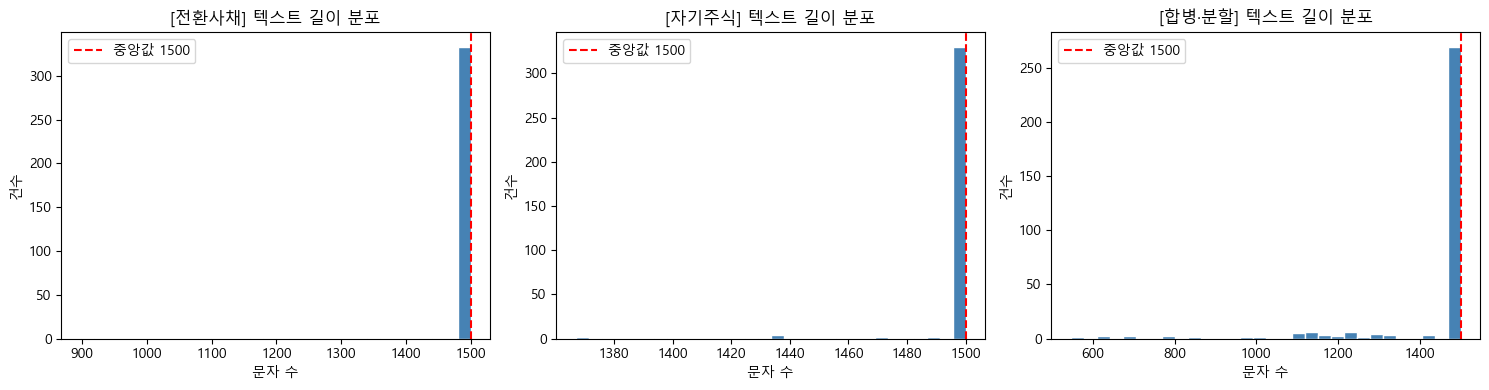

label       
자기주식   count     346.000000
       mean     1497.190751
       std        15.675275
       min      1367.000000
       25%      1500.000000
       50%      1500.000000
       75%      1500.000000
       max      1500.000000
전환사채   count     339.000000
       mean     1494.563422
       std        46.706796
       min       898.000000
       25%      1500.000000
       50%      1500.000000
       75%      1500.000000
       max      1500.000000
합병·분할  count     312.000000
       mean     1446.714744
       std       157.222349
       min       546.000000
       25%      1500.000000
       50%      1500.000000
       75%      1500.000000
       max      1500.000000
Name: text, dtype: float64


In [12]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글 폰트

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, label in zip(axes, meta_df["label"].unique()):
    lengths = meta_df[meta_df["label"] == label]["text"].str.len()
    ax.hist(lengths, bins=30, color="steelblue", edgecolor="white")
    ax.set_title(f"[{label}] 텍스트 길이 분포")
    ax.set_xlabel("문자 수")
    ax.set_ylabel("건수")
    ax.axvline(lengths.median(), color="red", linestyle="--", label=f"중앙값 {lengths.median():.0f}")
    ax.legend()

plt.tight_layout()
plt.show()

print(meta_df.groupby("label")["text"].apply(lambda s: s.str.len().describe()))

## 10. 저장

신규 3클래스 데이터만 `data/dart_corpus_v35_new.csv`에 저장합니다.  
기존 데이터와 병합은 `05_merge_and_finetune.ipynb`에서 수행합니다.

In [13]:
SAVE_PATH = "./data/dart_corpus_v35_new.csv"

# 저장 컬럼 통일 (기존 csv와 동일한 구조)
save_df = meta_df[["rcept_no", "corp_name", "report_nm", "rcept_dt", "label", "text"]]

save_df.to_csv(SAVE_PATH, index=False, encoding="utf-8-sig")

print(f"저장 완료: {SAVE_PATH}")
print(f"총 {len(save_df):,}개 샘플")
print()
print(save_df["label"].value_counts())
print()
print("텍스트 길이 통계:")
print(save_df["text"].str.len().describe())

저장 완료: ./data/dart_corpus_v35_new.csv
총 997개 샘플

label
자기주식     346
전환사채     339
합병·분할    312
Name: count, dtype: int64

텍스트 길이 통계:
count     997.000000
mean     1480.501505
std        95.213042
min       546.000000
25%      1500.000000
50%      1500.000000
75%      1500.000000
max      1500.000000
Name: text, dtype: float64


## 11. 수집 결과 요약

아래 셀로 기존 데이터와 비교해 병합 준비 상태를 확인합니다.

In [15]:
# 기존 데이터
old_df = pd.read_csv("./data/dart_corpus_text.csv")
new_df = pd.read_csv(SAVE_PATH)

print("=" * 50)
print("[기존 데이터 — dart_corpus_text.csv]")
print(f"  총 샘플: {len(old_df):,}건")
print(old_df["label"].value_counts().to_string())

print()
print("[신규 데이터 — dart_corpus_v35_new.csv]")
print(f"  총 샘플: {len(new_df):,}건")
print(new_df["label"].value_counts().to_string())

combined = pd.concat([old_df, new_df], ignore_index=True)
print()
print("[병합 후 예상 — 6클래스]")
print(f"  총 샘플: {len(combined):,}건")
print(combined["label"].value_counts().to_string())

# rcept_no 중복 체크
dup = combined.duplicated(subset="rcept_no").sum()
print(f"\n⚠️ rcept_no 중복: {dup}건 (병합 시 제거 필요)")

[기존 데이터 — dart_corpus_text.csv]
  총 샘플: 979건
label
사업보고서    355
감사보고서    316
유상증자     308

[신규 데이터 — dart_corpus_v35_new.csv]
  총 샘플: 997건
label
자기주식     346
전환사채     339
합병·분할    312

[병합 후 예상 — 6클래스]
  총 샘플: 1,976건
label
사업보고서    355
자기주식     346
전환사채     339
감사보고서    316
합병·분할    312
유상증자     308

⚠️ rcept_no 중복: 0건 (병합 시 제거 필요)


---

## ✅ 다음 단계

수집 결과가 정상이면 **`05_finetune_v35.ipynb`** 로 이동합니다.

```
dart_corpus_text.csv     (기존 3클래스, 979건)
        +
dart_corpus_v35_new.csv  (신규 3클래스, ~900건)
        ↓ 병합 + 중복 제거
dart_corpus_v35.csv      (6클래스, ~1,800건)
        ↓ Warm-start 재학습
models/dart_classifier_v35/
```

### 문제 대응 가이드

| 상황 | 대처 |
|---|---|  
| document.xml status 101 다수 | 섹션 7-B 실행 (보고서명 fallback) |
| 클래스별 건수 차이 큼 (2배 이상) | 많은 클래스 다운샘플링 또는 class_weight 적용 |
| 특정 클래스 100건 미만 | 수집 기간 확대 (2021년 추가) 또는 target 수정 후 재수집 |